In [2]:
import parcels
import math
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import scipy

import trajan
import cartopy.crs as ccrs
import cartopy.feature
from datetime import datetime, timedelta
import calculate_distance as c_d
import calculate_2DHistogram_method01 as c_H

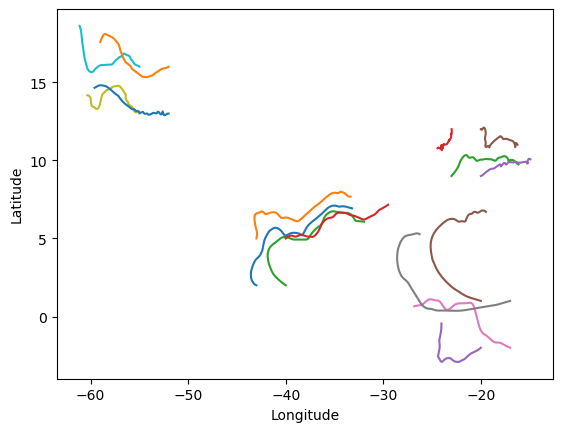

/nethome/6903894/parcels_env/lib/python3.13/site-packages/xarray/coding/times.py:645: RuntimeWarning: invalid value encountered in cast
  flat_num = flat_num.astype(np.int64)


In [3]:
DSLA = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Simulations_part2/SIM_8sept_newgrid.zarr")
DSCG = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Simulations_part2/SIM_17sept_largegrid_growth.zarr")
DSLG = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Simulations_part2/SIM_17sept_largegrid.zarr")

DSMS = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Simulations_part2/SIM_22sept_try_strand.zarr")
DSAA = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Simulations_part2/SIM_22sept_largegrid_g_s.zarr")

#Starttime definition
starttimejuly = datetime(2024,7,1)

#Definition of time array
time_in_hours = ((DSLA['time']-DSLA['time'][:,0]).astype("timedelta64[h]"))

time_in_days = ((DSLA['time'] - DSLA['time'][:, 0]).astype("timedelta64[h]")).astype(float) / 24

plt.plot(DSMS.lon.T, DSMS.lat.T, "-")

#plt.scatter(lon,lat, s=1)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [4]:
#PROBABILITY DENSITY FUNCTION

#This code bins the particle positions into histograms at each timestep using np.histogram2D. The result is a heat map of the cumulative particle density over time which, when normalised by the total number of particle positions, yields a probability map.

#Author: Jimena Medina Rubio

#Created on: 18/03/2023

#0. Imports and package versions
import parcels
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cmocean
import cmocean.cm as cmo
import pandas as pd

#. DEFINITION OF FUNCTIONS

def probability_density(ds, bins_x, bins_y):
    
    """
    Calculates the COUNT of the longitude and latitude coordinates of the trajectories at each observation.
    
    Input variables
    -ds: OceanParcels output of lon & lat of each particle at each timestep
    -bins_x & bins_y: number of bins in x/y direction 
    """

    def histogram(lon, lat, bins_x, bins_y): 
        
        #define the coordinates of the edges of the bins
        bins_edges_x = np.histogram_bin_edges(lon, bins=bins_x)
        bins_edges_y = np.histogram_bin_edges(lat, bins=bins_y)
        
        #calculate the 2D normalised histogram & bin edges
        H, x, y = np.histogram2d(lon.flatten(), lat.flatten(), bins=[bins_edges_x, bins_edges_y], density=False)
        return H, x, y
    
    #apply histogram function to all trajectories at every observation
    result = xr.apply_ufunc(
        histogram,
        ds['lon'].values,
        ds['lat'].values,
        bins_x,
        bins_y,
        input_core_dims=[['traj', 'obs'], ['traj', 'obs'], [], []],
        output_core_dims=[['binx', 'biny'], [], []],
        dask='parallelized',
        vectorize=True,
        output_dtypes=[float])
    
    #define the bin centres from the output bin edges
    bins_centres_x=np.linspace(result[1][0], result[1][-1], len(result[1])-1)
    bins_centres_y=np.linspace(result[2][0], result[2][-1], len(result[2])-1)
    
    #convert particle counts per grid cell into a data array
    da_result = xr.DataArray(result[0], 
                             dims=['binx', 'biny'], 
                             coords={'binx': bins_centres_x, 'biny': bins_centres_y}, name='Count') 
    
    #set values equal to zero to NaN 
    da_result = da_result.where(da_result != 0, np.nan)
    
    return da_result.T

def probability_map(probability, xlim, ylim, title, da_velocity):
    
    """ All-included plot of the desired domain specified by xlim & ylim """
    
    fig=plt.figure(figsize=(13,6)) 
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree(central_longitude=0.0))

    #create grid
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    
    #choose: plot coastlines or velocity field stored in data array
    if np.all(da_velocity is None):
        ax.coastlines(resolution='10m')
        ax.add_feature(cartopy.feature.LAND, facecolor='grey')
    else:   
        da_velocity.plot(ax=ax, cmap=cmo.balance, alpha=0.7)

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
    gl.right_labels = False
    gl.top_labels = False

    #plotting probability results 
    probability.plot(ax=ax, cmap=cmo.matter)
    plt.title(title)
                
    return plt.show(

    )

Frozen({'trajectory': 3536, 'obs': 400})
FrozenMappingWarningOnValuesAccess({'trajectory': 3536, 'obs': 400})
Frozen({'trajectory': 3536, 'obs': 372})
Frozen({'trajectory': 3536})


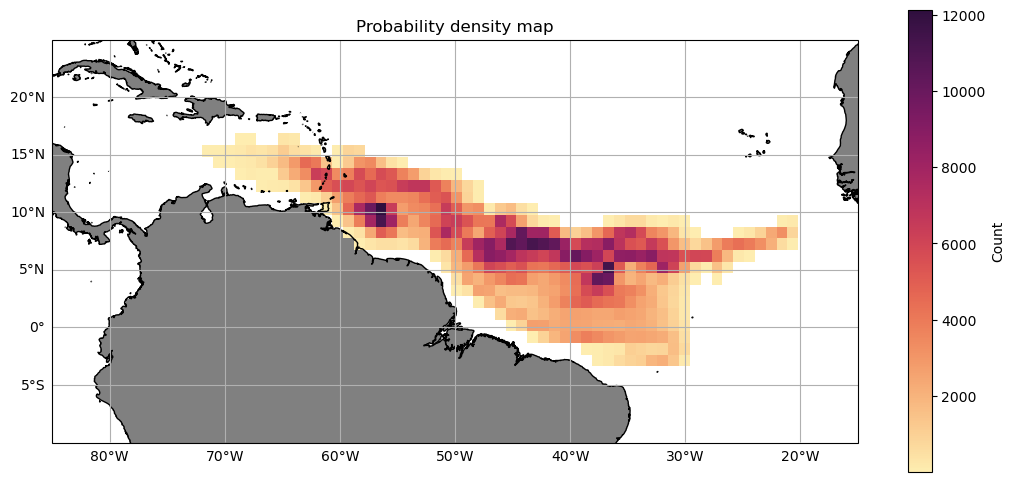

In [5]:
bins_x = 55
bins_y = 20

print(DSLA.sizes)
print(DSLA.dims)

DSLAN = DSLA.dropna(dim='obs' , how='all')
DSLAN_lasttimestep = DSLAN.isel(obs=-1)

print(DSLAN.sizes)
print(DSLAN_lasttimestep.sizes)

probability = probability_density(DSLAN, bins_x, bins_y)
probability_last = probability_density(DSLAN_lasttimestep, bins_x, bins_y)

#choose the limits of the x & y axis of the graph
xlim=[-85, -15]
ylim= [-10, 25]

#plot the results
probability_map(probability, xlim, ylim, 'Probability density map', None)

(20, 55)


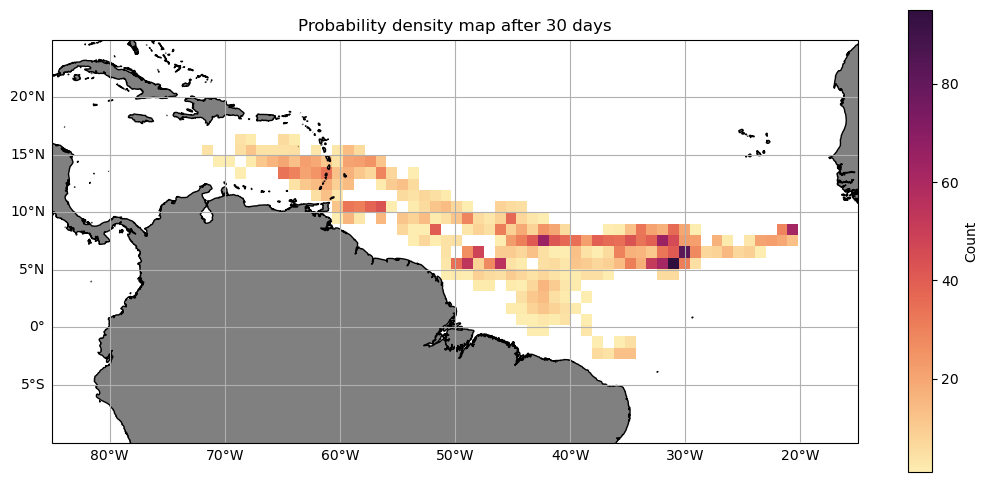

3536.0


In [9]:
#plot the results
print(probability_last.shape)

probability_map(probability_last, xlim, ylim, 'Probability density map after 30 days', None)

hi = probability_last.values
print(np.nansum(hi))

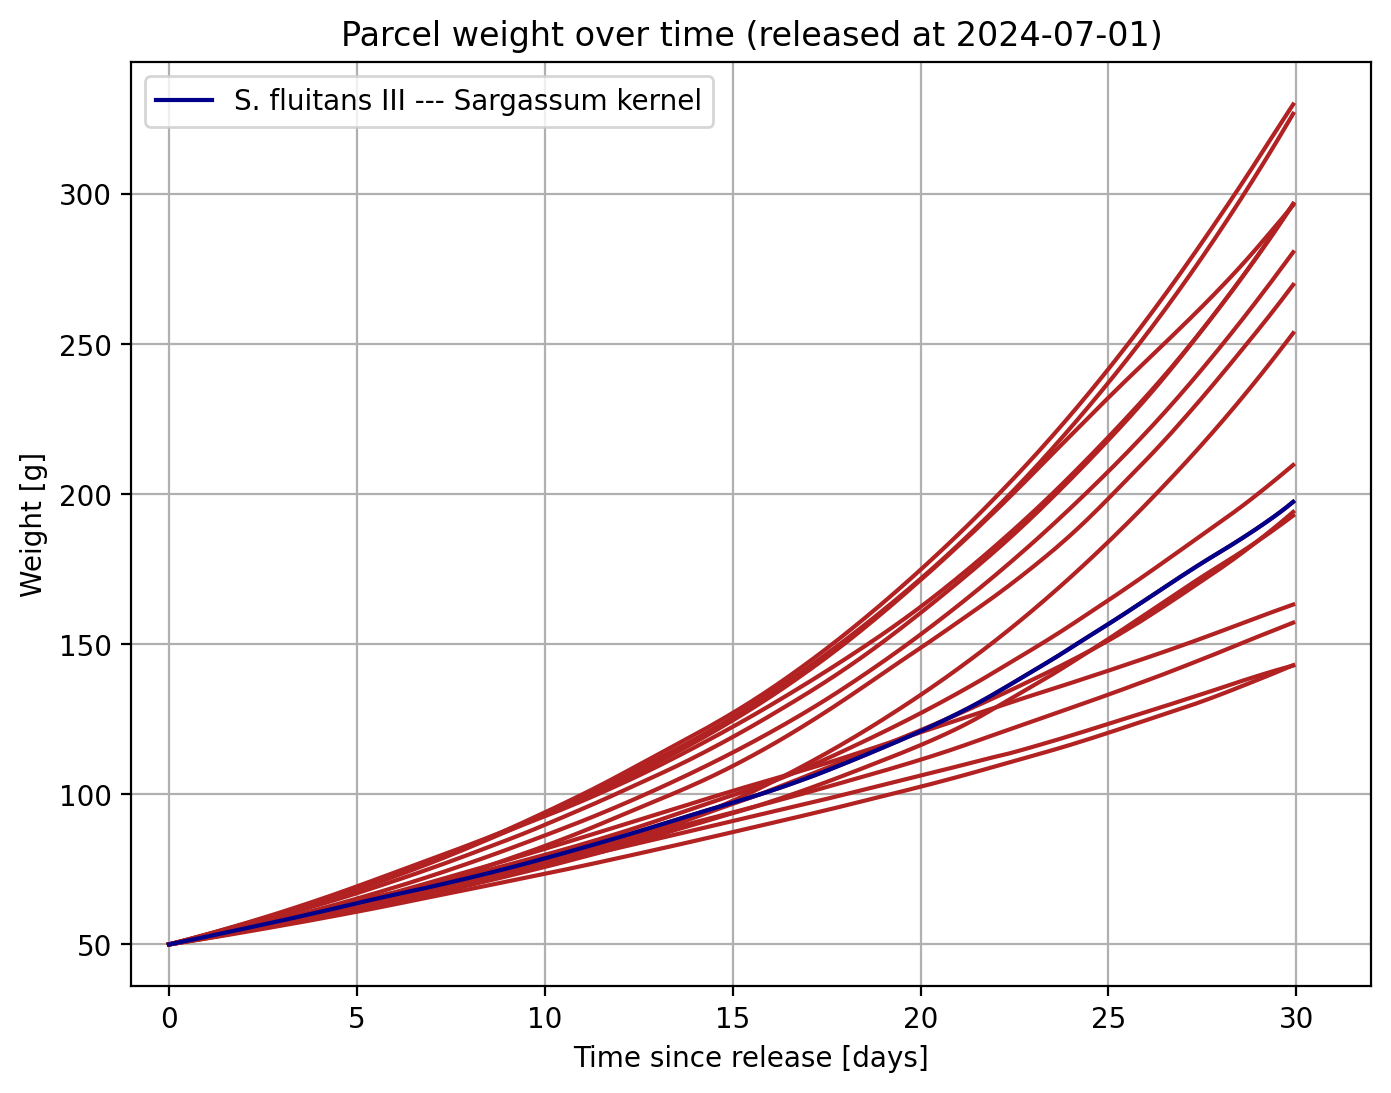

In [51]:
#Definition of time array
time_in_hours = ((DSCG['time']-DSCG['time'][:,0]).astype("timedelta64[h]"))
time_in_days = ((DSCG['time'] - DSCG['time'][:, 0]).astype("timedelta64[h]")).astype(float) / 24

figweight = plt.figure(figsize = (8,6), dpi=200)

plt.plot(time_in_days.transpose(), DSCG.weight_SF3.transpose() , c = 'firebrick')
#plt.plot(time_in_days.transpose(), DS.weight_SF3.transpose() ,c = 'darkblue')

plt.plot(time_in_days[0,:].transpose(), DSCG.weight_SF3[0,:].transpose() , c = 'darkblue', label = 'S. fluitans III --- Sargassum kernel')
#plt.plot(time_in_days[0,:].transpose(), DSB.weight_SF3[0,:].transpose() , c = 'firebrick', label = 'S. fluitans III --- Bonner et al. (2024)')

plt.title(f'Parcel weight over time (released at {starttimejuly.date()})')
plt.xlabel('Time since release [days]')
plt.ylabel('Weight [g]')
#plt.yticks([50,70,90,110,130,150,170,190])
#plt.yticks([50,100,150])
plt.xlim(-1,32)
plt.legend()
plt.grid()
plt.show()

MAX:  329.92657  MIN:  50.013382
[  0.  50. 100. 150. 200. 250. 300. 350.]


/tmp/ipykernel_33973/3534888661.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('plasma', number_of_bins, )


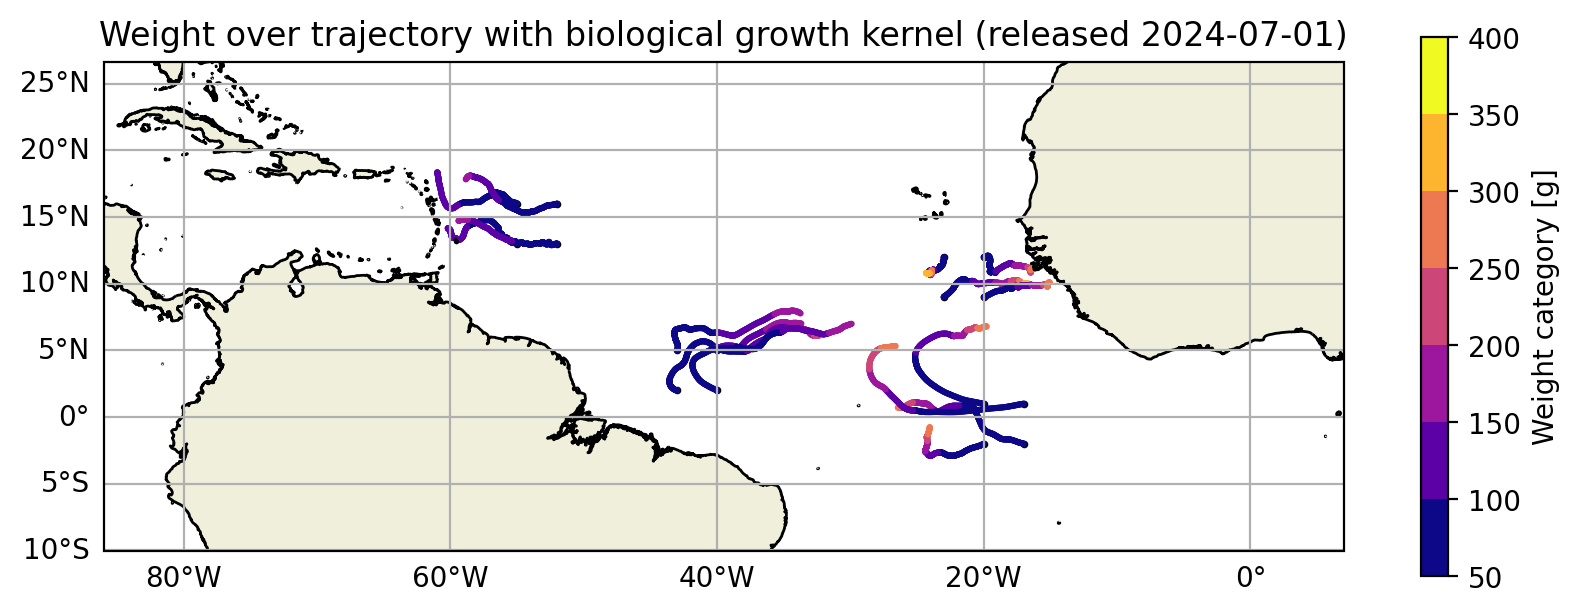

In [25]:
#SLICING TO REMOVE NAN VALUES AT THE END OF THE ARRAYS
DSCG_sliced = DSCG.isel(obs=slice(0, 372))

#Evaluating the min and max to be able to define the right categories
max_SF3 = np.nanmax(DSCG_sliced.weight_SF3)
min_SF3 = np.nanmin(DSCG_sliced.weight_SF3)
print('MAX: ', max_SF3, ' MIN: ',min_SF3)

#Defining the categories
div = np.linspace(0, 350, 8)
print(div)
div_step = div[1]-div[0]

#Categorizing based on weight and multiplying by category step size
categorized = np.digitize(DSCG_sliced.weight_SF3, div, right=False) * div_step

#Storing it in dataset
DSCG_sliced["weight_SF3_categorized"] = (DSCG_sliced.weight_SF3.dims, categorized) #Stores upper boundary of category that particle weight is in 

import matplotlib.colors as mcolors

fig = plt.figure(figsize = (10,7), dpi=200)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
#Startlocations scatterplot
#pplot = ax.scatter(DS_sliced.lon[:,:], DS_sliced.lat[:,:], s = 2 ,color='black') #Transposing lon and lat arrays!
pplot = ax.scatter(DSCG_sliced.lon[:,0], DSCG_sliced.lat[:,0], s = 3 ,color='black') #Transposing lon and lat arrays!

unique_categories = np.unique(categorized)
number_of_bins = len(unique_categories)
colormap = plt.cm.get_cmap('plasma', number_of_bins, )
boundaries = np.append(unique_categories - div_step, unique_categories[-1] ) 
norm = mcolors.BoundaryNorm(boundaries, number_of_bins)
#norm = mcolors.BoundaryNorm(np.append(unique_categories.min() - 50, , unique_categories.max()+1), number_of_bins)

# Colored scatter plot
cscat = ax.scatter(
    DSCG_sliced.lon, DSCG_sliced.lat, c = DSCG_sliced.weight_SF3_categorized.values - 1,
    cmap=colormap,
    norm=norm,
    s=5,
    linewidth=0,
    transform=ccrs.PlateCarree()
)

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))

ax.set_title(f'Weight over trajectory with biological growth kernel (released {starttimejuly.date()})')
ax.set_extent([-86,7,-7,19])
cbar = plt.colorbar(cscat, ax=ax, orientation='vertical', label='Weight category [g]', shrink=0.5)
plt.show()

/tmp/ipykernel_33973/22266628.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


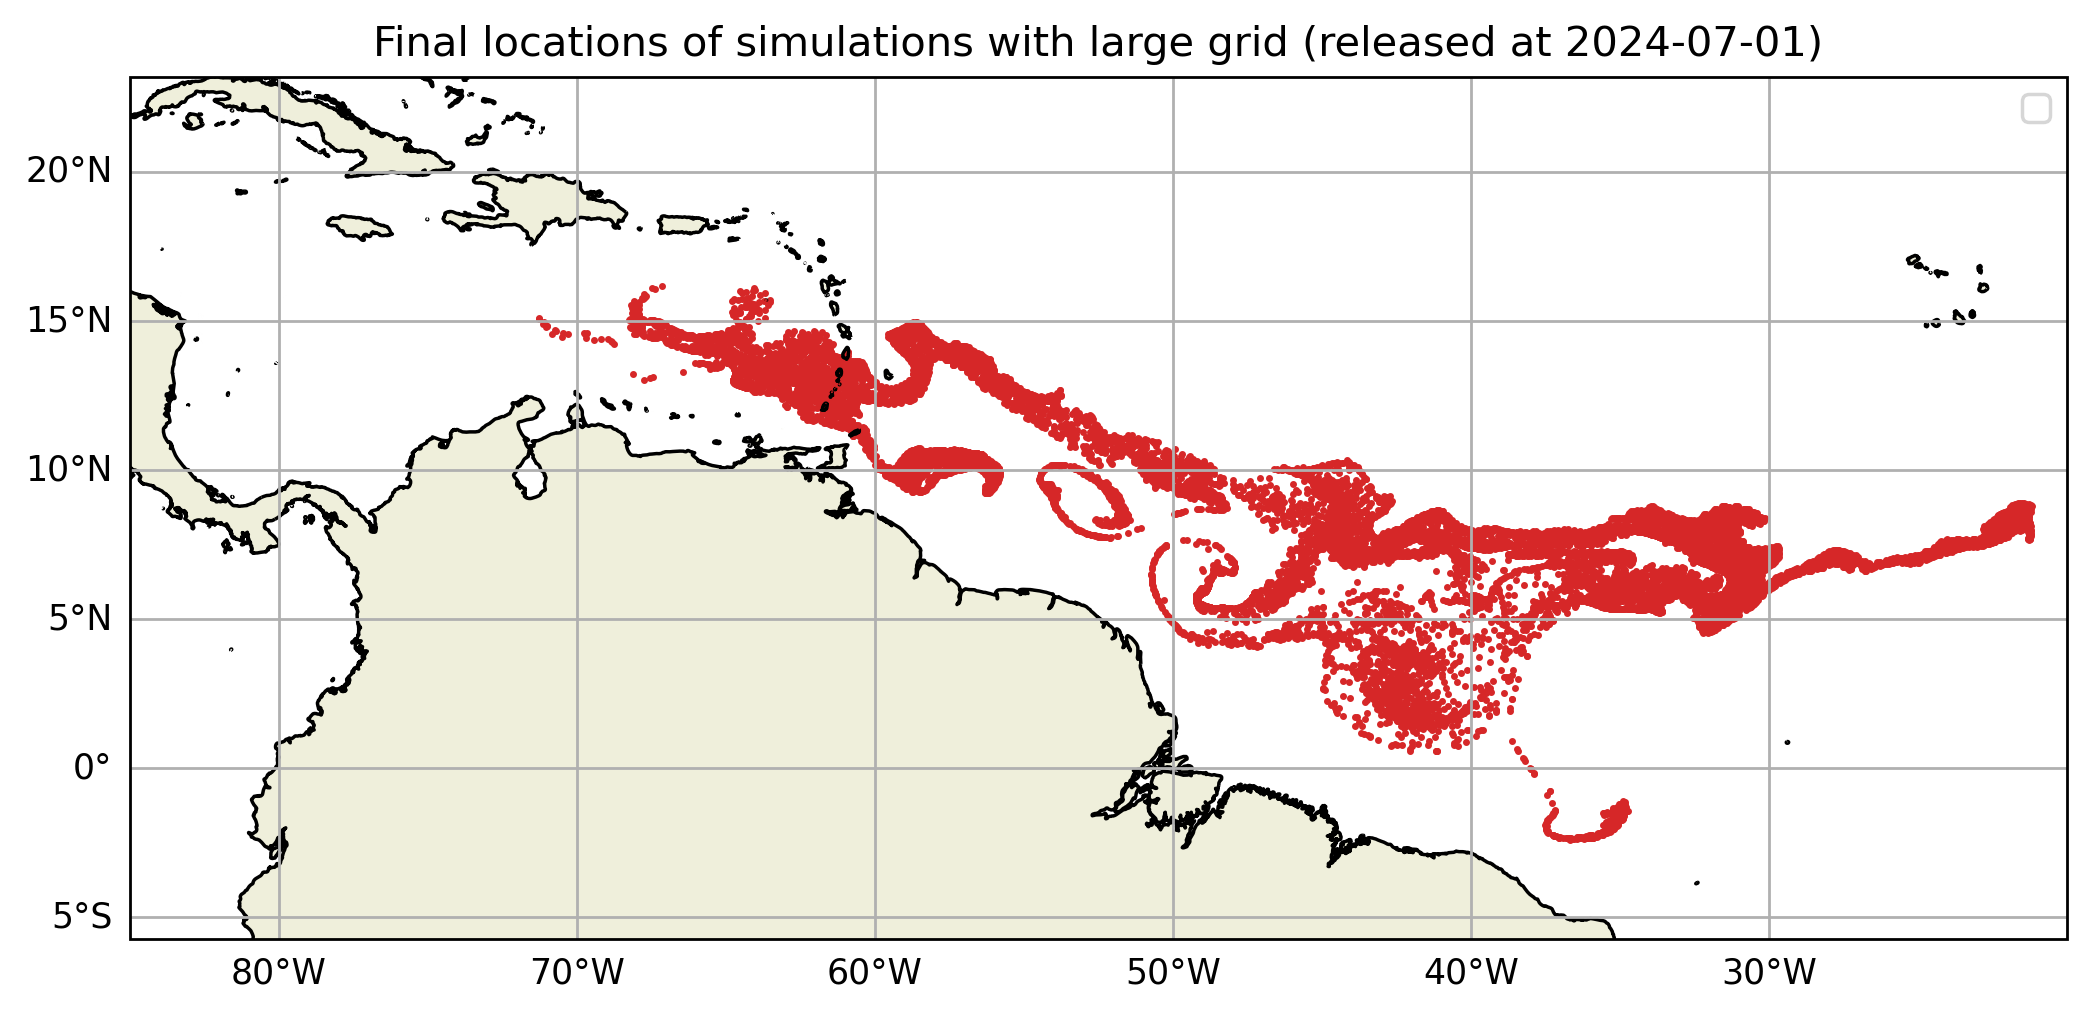

In [35]:
#SLICING TO REMOVE NAN VALUES AT THE END OF THE ARRAYS
DSCG_sliced = DSCG.isel(obs=slice(0, 350))

#Figure for plotting trajectories
fig2 = plt.figure(figsize = (10,7), dpi=250)
ax = plt.axes(projection=ccrs.PlateCarree())

#End locations scatterplot
eplot = ax.scatter(DSLG.lon[:,-41], DSLG.lat[:,-41], s = 1 ,color='tab:red') #Transposing lon and lat arrays!

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'Final locations of simulations with large grid (released at {starttimejuly.date()})')
ax.set_extent([-85,-20,-5,20])
#ax.set_extent([-86,7,-7,19])
ax.legend()
plt.show()


Frozen({'trajectory': 19825, 'obs': 400})
FrozenMappingWarningOnValuesAccess({'trajectory': 19825, 'obs': 400})
Frozen({'trajectory': 19825, 'obs': 372})
Frozen({'trajectory': 19825})


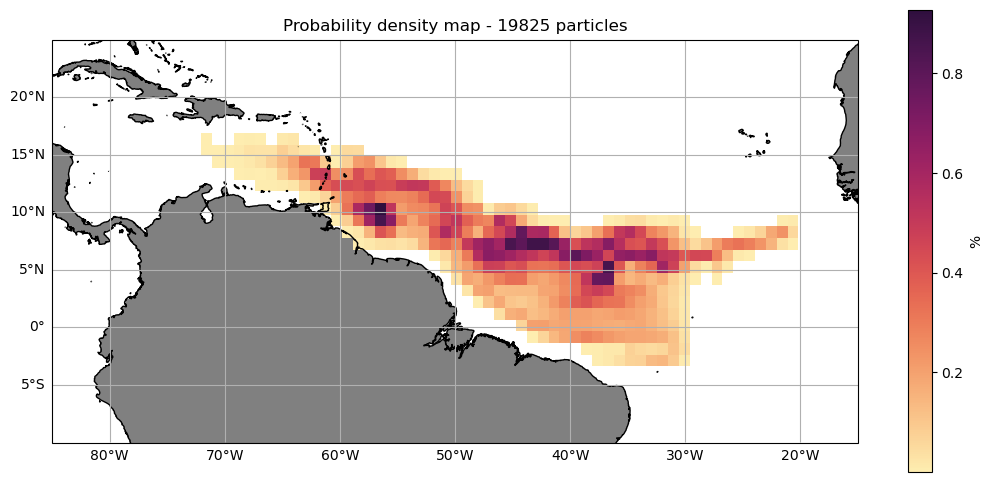

In [65]:
bins_x = 55
bins_y = 20

print(DSLG.sizes)
print(DSLG.dims)

DSLGN = DSLG.dropna(dim='obs' , how='all')
DSLGN_lasttimestep = DSLGN.isel(obs=-1)

print(DSLGN.sizes)
print(DSLGN_lasttimestep.sizes)

probability_lg = c_H.probability_density(DSLGN, bins_x, bins_y)
probability_lg_last = c_H.probability_density(DSLGN_lasttimestep, bins_x, bins_y)

#choose the limits of the x & y axis of the graph
xlim=[-85, -15]
ylim= [-10, 25]

#plot the results
probability_map(probability_lg, xlim, ylim, 'Probability density map - 19825 particles', None)

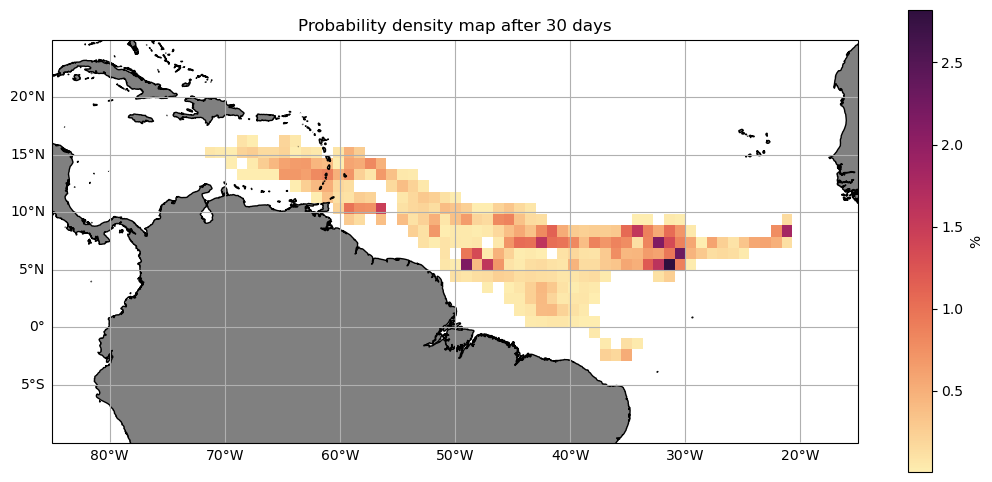

In [48]:
probability_map(probability_lg_last, xlim, ylim, 'Probability density map after 30 days', None)

Frozen({'trajectory': 19825, 'obs': 372})
Frozen({'trajectory': 19825})


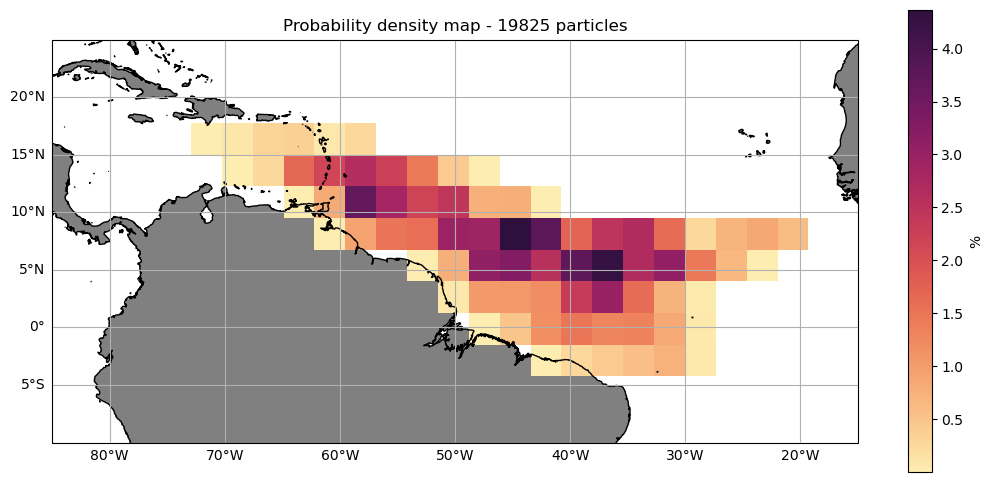

In [72]:
bins_x_large = 20
bins_y_large = 8

print(DSLGN.sizes)
print(DSLGN_lasttimestep.sizes)

probability_lg_large = c_H.probability_density(DSLGN, bins_x_large, bins_y_large)
probability_lg_last_large = c_H.probability_density(DSLGN_lasttimestep, bins_x_large, bins_y_large)

#choose the limits of the x & y axis of the graph
xlim=[-85, -15]
ylim= [-10, 25]

#plot the results
probability_map(probability_lg_large, xlim, ylim, 'Probability density map - 19825 particles', None)

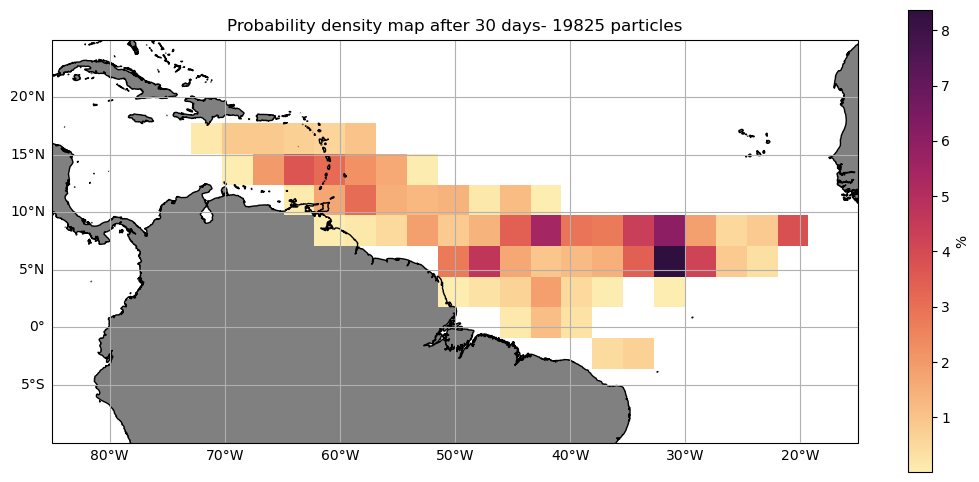

In [73]:
#plot the results
probability_map(probability_lg_last_large, xlim, ylim, 'Probability density map after 30 days- 19825 particles', None)

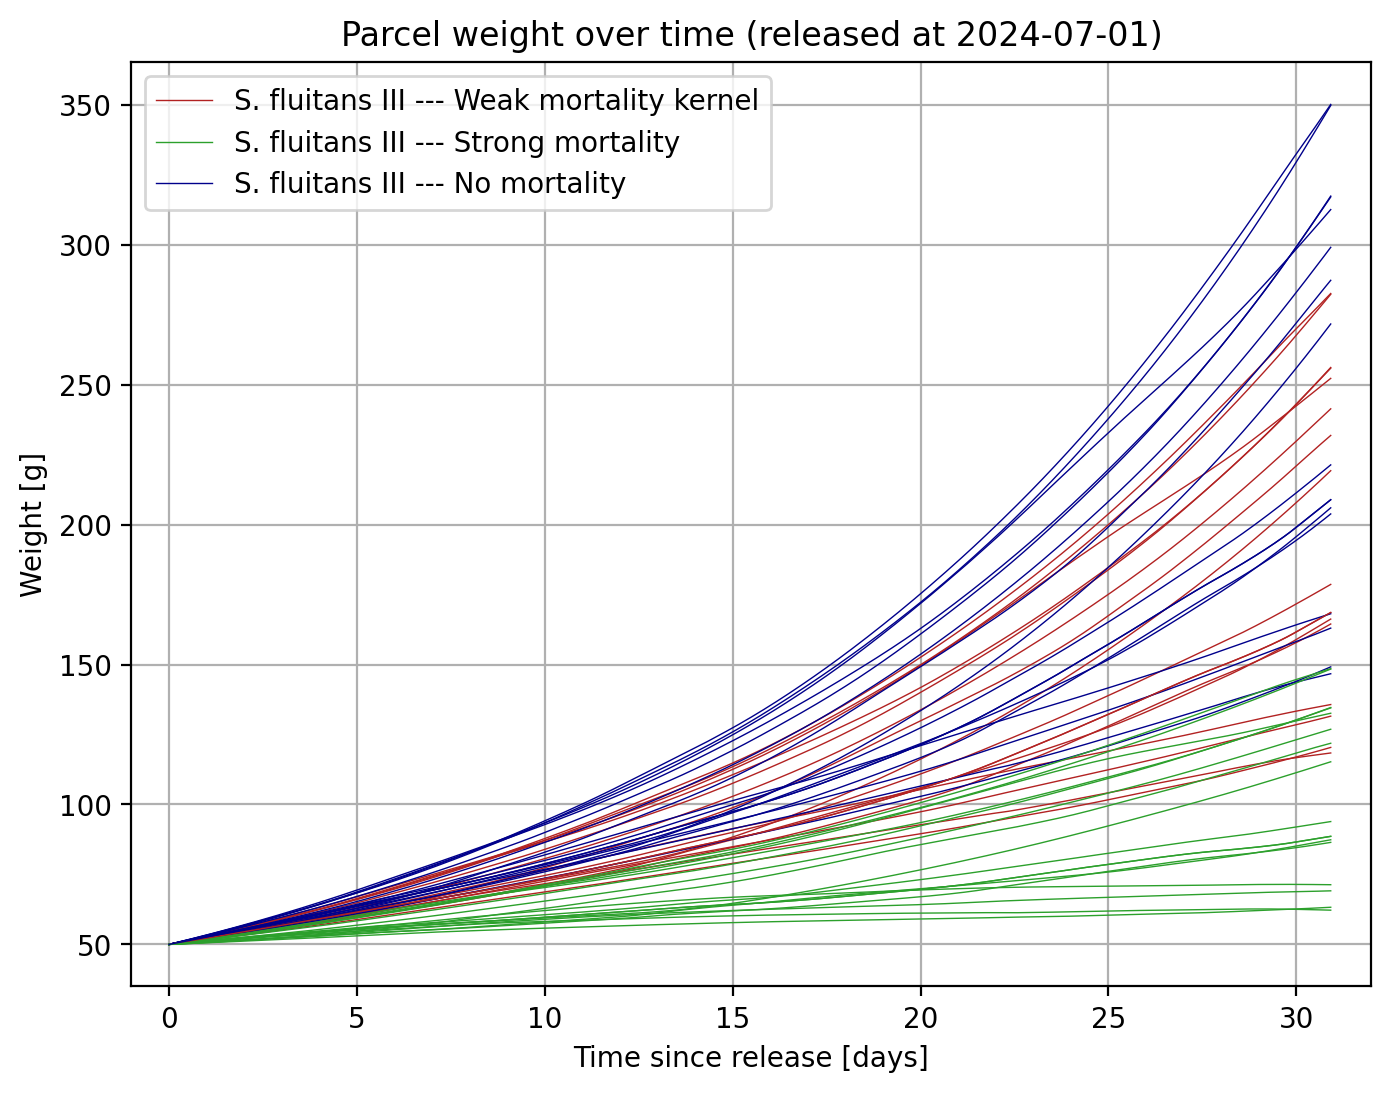

In [6]:
#Definition of time array
time_in_hours = ((DSMS['time']-DSMS['time'][:,0]).astype("timedelta64[h]"))
time_in_days = ((DSMS['time'] - DSMS['time'][:, 0]).astype("timedelta64[h]")).astype(float) / 24

figweight = plt.figure(figsize = (8,6), dpi=200)

plt.plot(time_in_days.transpose(), DSMS.weight_SF3.transpose() , c = 'firebrick', linewidth = 0.5)
plt.plot(time_in_days.transpose(), DSMS.weight_SN1.transpose() ,c = 'darkblue', linewidth = 0.5)
plt.plot(time_in_days.transpose(), DSMS.weight_SN8.transpose() ,c = 'tab:green', linewidth = 0.5)

plt.plot(time_in_days[0,:].transpose(), DSMS.weight_SF3[0,:].transpose() , c = 'firebrick', label = 'S. fluitans III --- Weak mortality kernel', linewidth = 0.5)
plt.plot(time_in_days[0,:].transpose(), DSMS.weight_SN8[0,:].transpose() , c = 'tab:green', label = 'S. fluitans III --- Strong mortality', linewidth = 0.5)
plt.plot(time_in_days[0,:].transpose(), DSMS.weight_SN1[0,:].transpose() , c = 'darkblue', label = 'S. fluitans III --- No mortality', linewidth = 0.5)


plt.title(f'Parcel weight over time (released at {starttimejuly.date()})')
plt.xlabel('Time since release [days]')
plt.ylabel('Weight [g]')
#plt.yticks([50,70,90,110,130,150,170,190])
#plt.yticks([50,100,150])
plt.xlim(-1,32)
plt.legend()
plt.grid()
plt.show()

(372,)


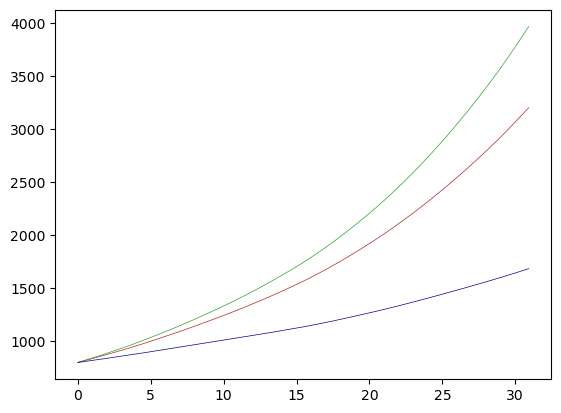

In [13]:
weight_sum = np.sum(DSMSN.weight_SF3, axis=0)
weight_sum2 = np.sum(DSMSN.weight_SN1, axis=0)
weight_sum3 = np.sum(DSMSN.weight_SN8, axis=0)

print(np.shape(weight_sum))

plt.plot(time_in_days[0,:372].transpose(), weight_sum.transpose() , c = 'firebrick', linewidth = 0.5)
plt.plot(time_in_days[0,:372].transpose(), weight_sum2.transpose() , c = 'tab:green', linewidth = 0.5)
plt.plot(time_in_days[0,:372].transpose(), weight_sum3.transpose() , c = 'darkblue', linewidth = 0.5)
plt.show()

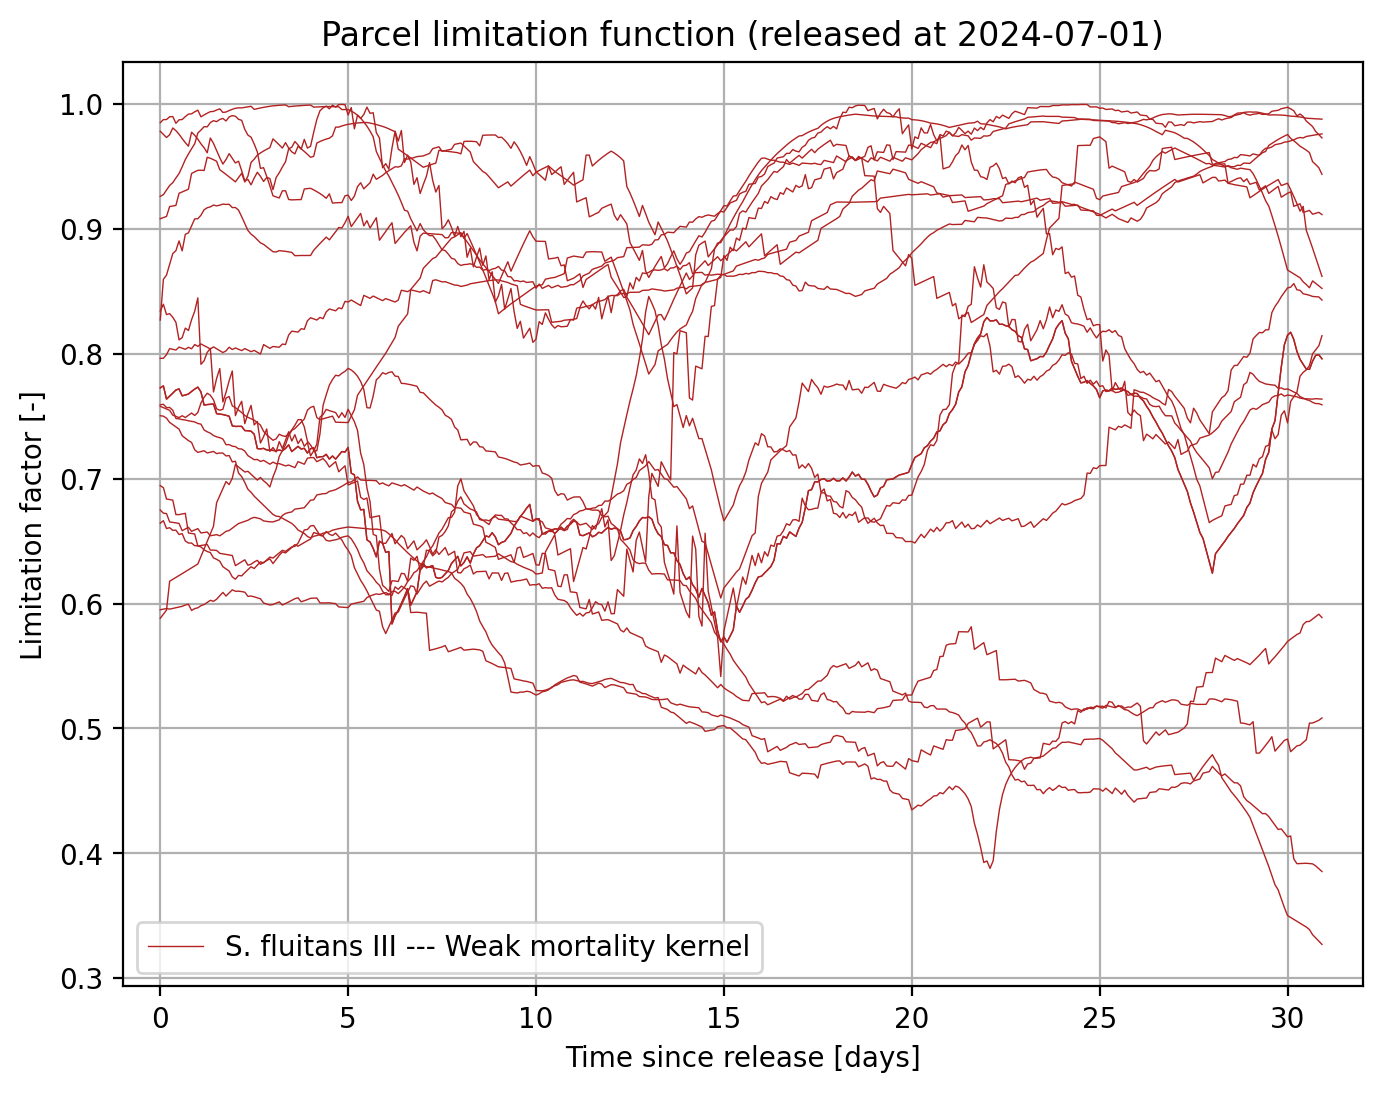

In [12]:
#Definition of time array
time_in_hours = ((DSMS['time']-DSMS['time'][:,0]).astype("timedelta64[h]"))
time_in_days = ((DSMS['time'] - DSMS['time'][:, 0]).astype("timedelta64[h]")).astype(float) / 24
figlim = plt.figure(figsize = (8,6), dpi=200)

plt.plot(time_in_days.transpose(), DSMS.limitation.transpose() , c = 'firebrick', linewidth = 0.5)
plt.plot(time_in_days[0,:].transpose(), DSMS.limitation[0,:].transpose() , c = 'firebrick', label = 'S. fluitans III --- Weak mortality kernel', linewidth = 0.5)

plt.title(f'Parcel limitation function (released at {starttimejuly.date()})')
plt.xlabel('Time since release [days]')
plt.ylabel('Limitation factor [-]')
#plt.yticks([50,70,90,110,130,150,170,190])
#plt.yticks([50,100,150])
plt.xlim(-1,32)
plt.legend()
plt.grid()
plt.show()

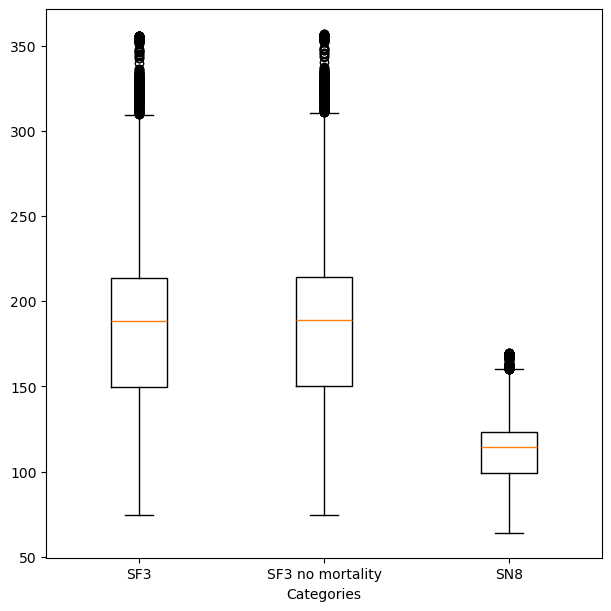

In [ ]:
DSLGN_lasttimestep['weight_SF3']

boxplot_list = [ DSLGN_lasttimestep['weight_SF3'], DSLGN_lasttimestep['weight_SN1'], DSLGN_lasttimestep['weight_SN8']]
names = ['SF3', 'SF3 no mortality', 'SN8']

boxplot = plt.figure(figsize=(6,6), constrained_layout=True, dpi=100)
#plt.boxplot(DSLGN_lasttimestep['weight_SF3'])
plt.boxplot(boxplot_list, tick_labels=names)
plt.xlabel('Categories')
plt.show()

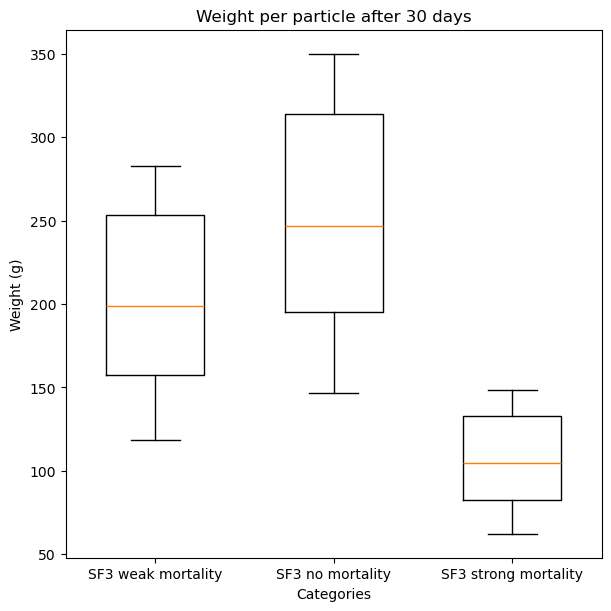

In [20]:
DSMSN = DSMS.dropna(dim='obs' , how='all')
DSMSN_lasttimestep = DSMSN.isel(obs=-1)

boxplot_list = [ DSMSN_lasttimestep['weight_SF3'], DSMSN_lasttimestep['weight_SN1'], DSMSN_lasttimestep['weight_SN8']]
names = ['SF3 weak mortality', 'SF3 no mortality', 'SF3 strong mortality']

boxplot = plt.figure(figsize=(6,6), constrained_layout=True, dpi=100)
#plt.boxplot(DSLGN_lasttimestep['weight_SF3'])
plt.boxplot(boxplot_list, tick_labels=names, widths=0.55)
plt.xlabel('Categories')
plt.ylabel('Weight (g)')
plt.title('Weight per particle after 30 days')
plt.show()

In [10]:
print(DSMSN_lasttimestep['stranded'].values)

print(len(DSMSN_lasttimestep))


[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
16


MAX:  282.55075  MIN:  50.011044
[  0.  50. 100. 150. 200. 250. 300. 350.]
yes
yessssss


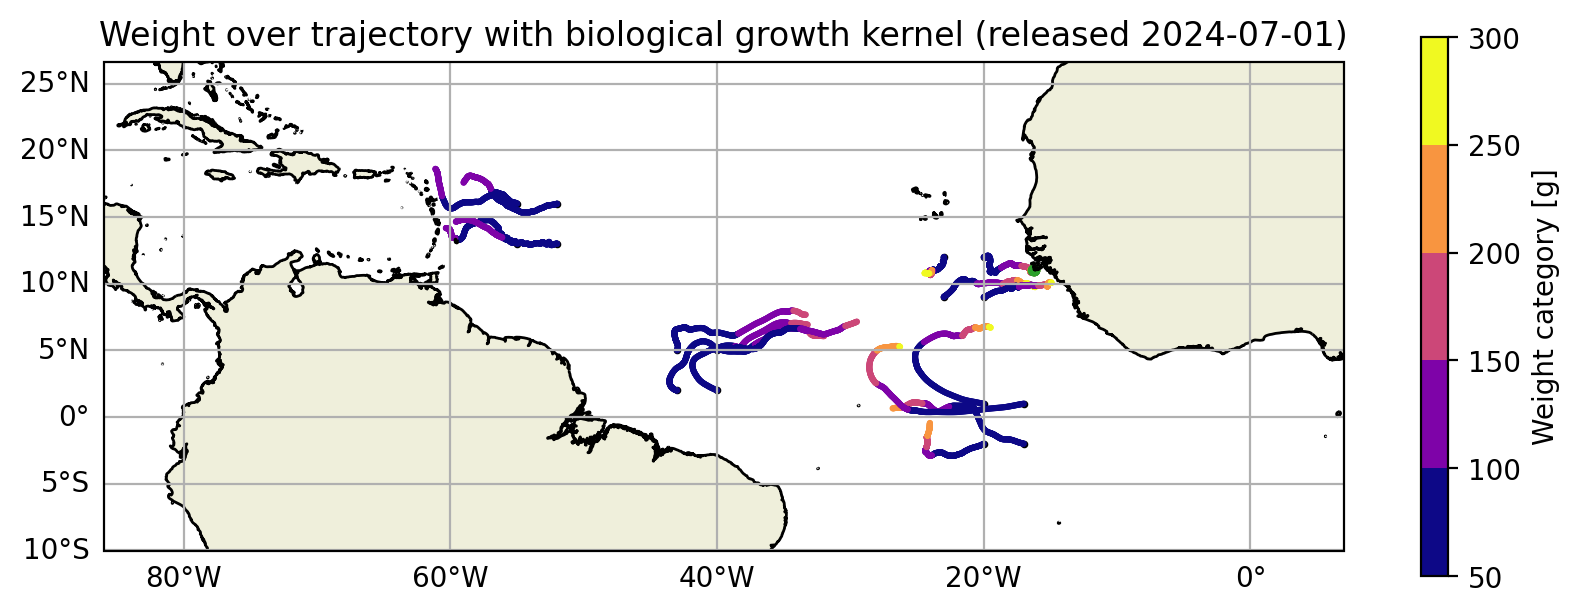

In [ ]:
#SLICING TO REMOVE NAN VALUES AT THE END OF THE ARRAYS
DSMSN = DSMS.dropna(dim='obs' , how='all')

#Evaluating the min and max to be able to define the right categories
max_SF3 = np.nanmax(DSMSN.weight_SF3)
min_SF3 = np.nanmin(DSMSN.weight_SF3)
print('MAX: ', max_SF3, ' MIN: ',min_SF3)

#Defining the categories
div = np.linspace(0, 350, 8)
print(div)
div_step = div[1]-div[0]

#Categorizing based on weight and multiplying by category step size
categorized = np.digitize(DSMSN.weight_SF3, div, right=False) * div_step

#Storing it in dataset
DSMSN["weight_SF3_categorized"] = (DSMSN.weight_SF3.dims, categorized) #Stores upper boundary of category that particle weight is in 

import matplotlib.colors as mcolors

fig = plt.figure(figsize = (10,7), dpi=200)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
#Startlocations scatterplot
#pplot = ax.scatter(DS_sliced.lon[:,:], DS_sliced.lat[:,:], s = 2 ,color='black') #Transposing lon and lat arrays!
pplot = ax.scatter(DSMSN.lon[:,0], DSMSN.lat[:,0], s = 3 ,color='black') #Transposing lon and lat arrays!

unique_categories = np.unique(categorized)
number_of_bins = len(unique_categories)
colormap = plt.cm.get_cmap('plasma', number_of_bins, )
boundaries = np.append(unique_categories - div_step, unique_categories[-1] ) 
norm = mcolors.BoundaryNorm(boundaries, number_of_bins)
#norm = mcolors.BoundaryNorm(np.append(unique_categories.min() - 50, , unique_categories.max()+1), number_of_bins)

# Colored scatter plot
cscat = ax.scatter(
    DSMSN.lon, DSMSN.lat, c = DSMSN.weight_SF3_categorized.values - 1,
    cmap=colormap,
    norm=norm,
    s=5,
    linewidth=0,
    transform=ccrs.PlateCarree()
)

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))

if DSMSN_lasttimestep['stranded'].any() == 1:
    print('yes')
    mask = (DSMSN_lasttimestep['stranded']==1).compute()
    DSMSN_lasttimestep_slice = DSMSN_lasttimestep.where(mask, drop=True)
    #print(DSMSN_lasttimestep_slice)
    ax.scatter(DSMSN_lasttimestep_slice.lon, DSMSN_lasttimestep_slice.lat, c='red', s=10)
else:
    print('no')

if DSMSN['stranded'].any() == 1:
    print('yessssss')
    mask2 = (DSMSN['stranded']==1).compute()
    DSMSN_slice = DSMSN.where(mask2, drop=True)
    #print(DSMSN_lasttimestep_slice)
    ax.scatter(DSMSN_slice.lon, DSMSN_slice.lat, c='tab:green', s=10)
else:
    print('no')

ax.set_title(f'Weight over trajectory with biological growth kernel (released {starttimejuly.date()})')
ax.set_extent([-86,7,-7,19])
cbar = plt.colorbar(cscat, ax=ax, orientation='vertical', label='Weight category [g]', shrink=0.5)
plt.show()

/tmp/ipykernel_65163/3220026121.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('plasma', number_of_bins )


[200. 200. 200. 200. 250. 300. 250. 300. 150. 150. 150. 150. 300. 300.
 300. 250.]
Frozen({'trajectory': 16, 'obs': 372})
there are stranded particles


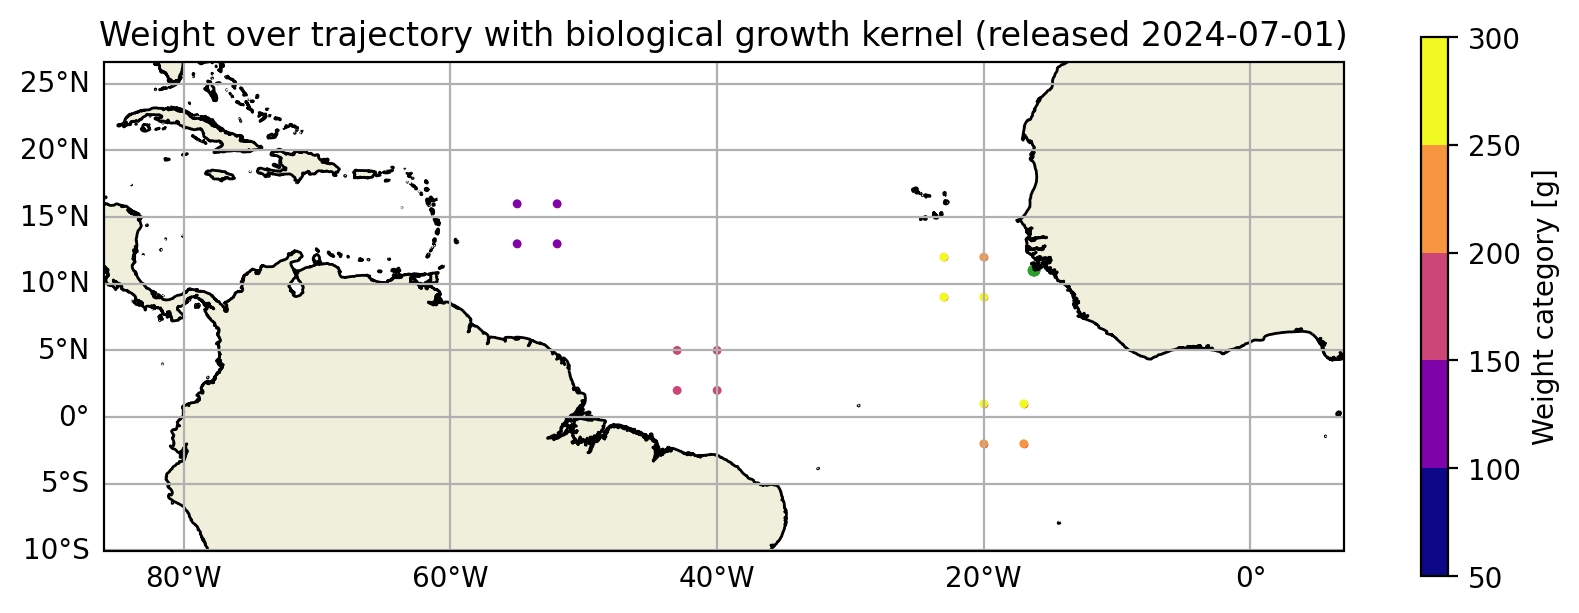

In [53]:
fig = plt.figure(figsize = (10,7), dpi=200)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
#Startlocations scatterplot
#pplot = ax.scatter(DS_sliced.lon[:,:], DS_sliced.lat[:,:], s = 2 ,color='black') #Transposing lon and lat arrays!
pplot = ax.scatter(DSMSN.lon[:,0], DSMSN.lat[:,0], s = 3 ,color='red') #Transposing lon and lat arrays!

unique_categories = np.unique(categorized)
number_of_bins = len(unique_categories)
colormap = plt.cm.get_cmap('plasma', number_of_bins )
boundaries = np.append(unique_categories - div_step, unique_categories[-1] ) 
norm = mcolors.BoundaryNorm(boundaries, number_of_bins)
#norm = mcolors.BoundaryNorm(np.append(unique_categories.min() - 50, , unique_categories.max()+1), number_of_bins)

print(DSMSN.weight_SF3_categorized[:,-1].values)

print(DSMSN.sizes)
# Colored scatter plot
cscat = ax.scatter(
    DSMSN.lon[:,0], DSMSN.lat[:,0], c = DSMSN.weight_SF3_categorized[:,-1].values - 1,
    cmap=colormap,
    norm=norm,
    s=10,
    linewidth=0,
    transform=ccrs.PlateCarree()
)

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))

if DSMSN['stranded'].any() == 1:
    print('there are stranded particles')
    mask2 = (DSMSN['stranded']==1).compute()
    DSMSN_slice = DSMSN.where(mask2, drop=True)
    ax.scatter(DSMSN_slice.lon, DSMSN_slice.lat, c='tab:green', s=10)
else:
    print('no')

ax.set_title(f'Weight over trajectory with biological growth kernel (released {starttimejuly.date()})')
ax.set_extent([-86,7,-7,19])
cbar = plt.colorbar(cscat, ax=ax, orientation='vertical', label='Weight category [g]', shrink=0.5)
plt.show()

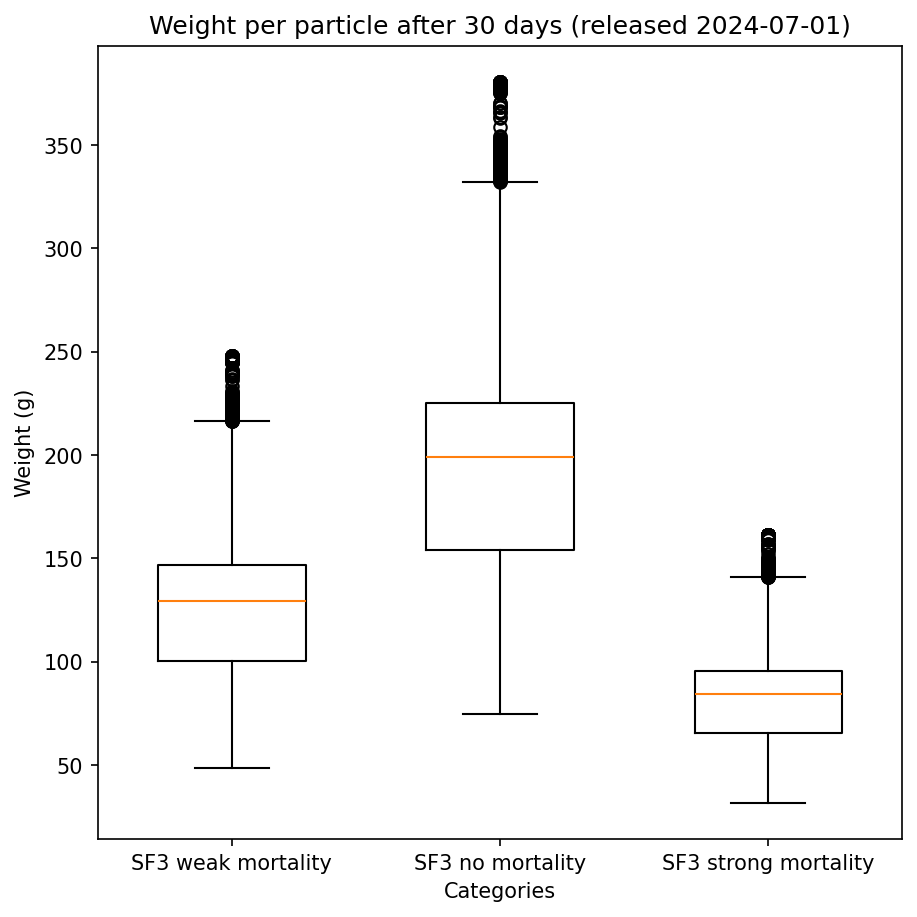

In [63]:
#NEWEST SIMULATIONS

DSAAN = DSAA.dropna(dim='obs' , how='all')
DSAAN_lasttimestep = DSAAN.isel(obs=-1)

boxplot_list = [ DSAAN_lasttimestep['weight_SF3'], DSAAN_lasttimestep['weight_SN1'], DSAAN_lasttimestep['weight_SN8']]
boxplot_names = ['SF3 weak mortality', 'SF3 no mortality', 'SF3 strong mortality']

boxplot = plt.figure(figsize=(6,6), constrained_layout=True, dpi=150)
#plt.boxplot(DSLGN_lasttimestep['weight_SF3'])
plt.boxplot(boxplot_list, tick_labels=boxplot_names, widths=0.55)
plt.xlabel('Categories')
plt.ylabel('Weight (g)')

plt.title(f'Weight per particle after 30 days (released {starttimejuly.date()})')
plt.show()

(372,)


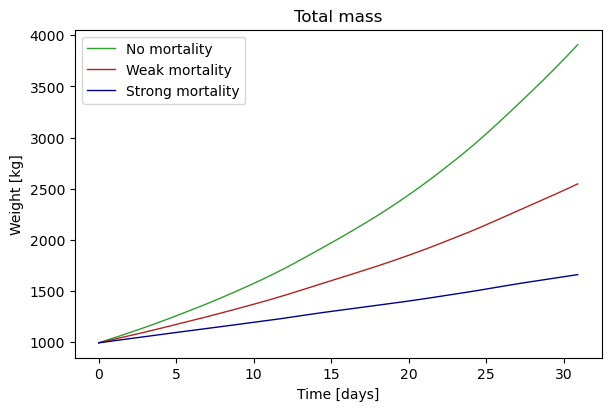

In [75]:
weight_sum = np.sum(DSAAN.weight_SF3, axis=0)/1000
weight_sum2 = np.sum(DSAAN.weight_SN1, axis=0)/1000
weight_sum3 = np.sum(DSAAN.weight_SN8, axis=0)/1000

print(np.shape(weight_sum))

weightplot = plt.figure(figsize=(6,4), constrained_layout=True)
plt.plot(time_in_days[0,:372].transpose(), weight_sum2.transpose() , c = 'tab:green', linewidth =1, label='No mortality')
plt.plot(time_in_days[0,:372].transpose(), weight_sum.transpose() , c = 'firebrick', linewidth = 1, label='Weak mortality')

plt.plot(time_in_days[0,:372].transpose(), weight_sum3.transpose() , c = 'darkblue', linewidth = 1, label='Strong mortality')
plt.xlabel('Time [days]')
plt.ylabel('Weight [kg]')
plt.title('Total mass')
plt.legend()
plt.show()

In [28]:
stranded_particles = np.sum(DSAAN.stranded, axis=0)
print(stranded_particles.values)
print(len(stranded_particles))
print(np.sum(stranded_particles.values))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

MAX:  380.46335  MIN:  50.01024
[  0.  50. 100. 150. 200. 250. 300. 350. 400.]
[150. 150. 150. ... 300. 300. 300.]
Frozen({'trajectory': 19825, 'obs': 372})


/tmp/ipykernel_65163/3722558392.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('plasma', number_of_bins )


no stranded particles


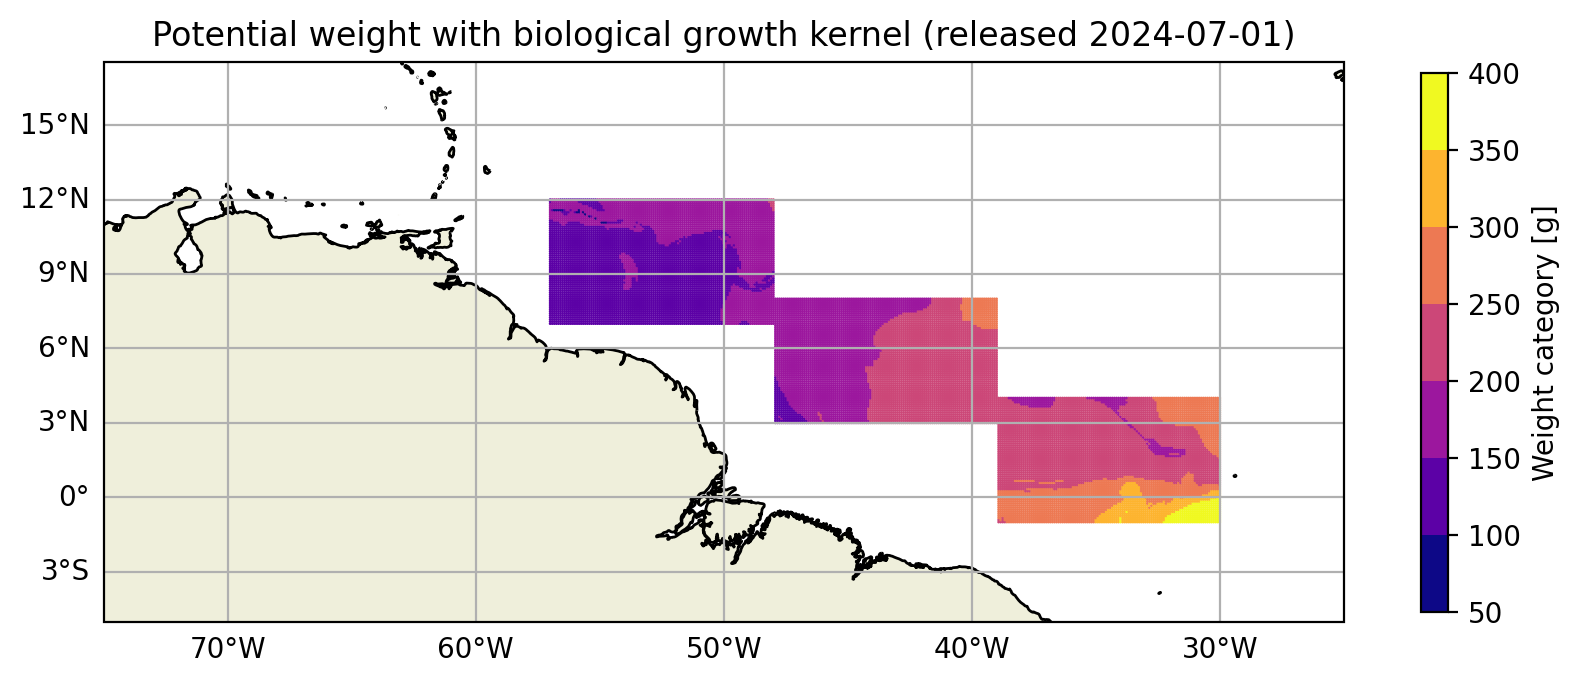

In [77]:
#Evaluating the min and max to be able to define the right categories
max_SF3 = np.nanmax(DSAAN.weight_SN1)
min_SF3 = np.nanmin(DSAAN.weight_SN1)
print('MAX: ', max_SF3, ' MIN: ',min_SF3)

#Defining the categories
div = np.linspace(0, 400, 9)
print(div)
div_step = div[1]-div[0]

#Categorizing based on weight and multiplying by category step size
categorized = np.digitize(DSAAN.weight_SN1, div, right=False) * div_step

#Storing it in dataset
DSAAN["weight_SF3_categorized"] = (DSAAN.weight_SF3.dims, categorized) #Stores upper boundary of category that particle weight is in 

fig = plt.figure(figsize = (10,7), dpi=200)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.gridlines(draw_labels=['left','bottom'], zorder=0)

#Startlocations scatterplot
#pplot = ax.scatter(DSAAN.lon[:,0], DSAAN.lat[:,0], s = 3 ,color='red') #Transposing lon and lat arrays!

unique_categories = np.unique(categorized)
number_of_bins = len(unique_categories)
colormap = plt.cm.get_cmap('plasma', number_of_bins )
boundaries = np.append(unique_categories - div_step, unique_categories[-1] ) 
norm = mcolors.BoundaryNorm(boundaries, number_of_bins)
#norm = mcolors.BoundaryNorm(np.append(unique_categories.min() - 50, , unique_categories.max()+1), number_of_bins)

print(DSAAN.weight_SF3_categorized[:,-1].values)

print(DSAAN.sizes)
# Colored scatter plot
cscat = ax.scatter(
    DSAAN.lon[:,0], DSAAN.lat[:,0], c = DSAAN.weight_SF3_categorized[:,-1].values - 1,
    cmap=colormap,
    norm=norm,
    s=1,
    linewidth=0,
    transform=ccrs.PlateCarree()
)

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))

if DSAAN['stranded'].any() == 1:
    print('there are stranded particles')
    mask2 = (DSAAN['stranded']==1).compute()
    DSAAN_slice = DSAAN.where(mask2, drop=True)
    ax.scatter(DSAAN_slice.lon, DSAAN_slice.lat, c='tab:green', s=10)
else:
    print('no stranded particles')

ax.set_title(f'Potential weight with biological growth kernel (released {starttimejuly.date()})')
#ax.set_extent([-86,7,-7,19])
ax.set_extent([-75,-25,-5,16])
cbar = plt.colorbar(cscat, ax=ax, orientation='vertical', label='Weight category [g]', shrink=0.5)
plt.show()

/tmp/ipykernel_65163/3220026121.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('plasma', number_of_bins )


[200. 200. 200. 200. 250. 300. 250. 300. 150. 150. 150. 150. 300. 300.
 300. 250.]
Frozen({'trajectory': 16, 'obs': 372})
there are stranded particles


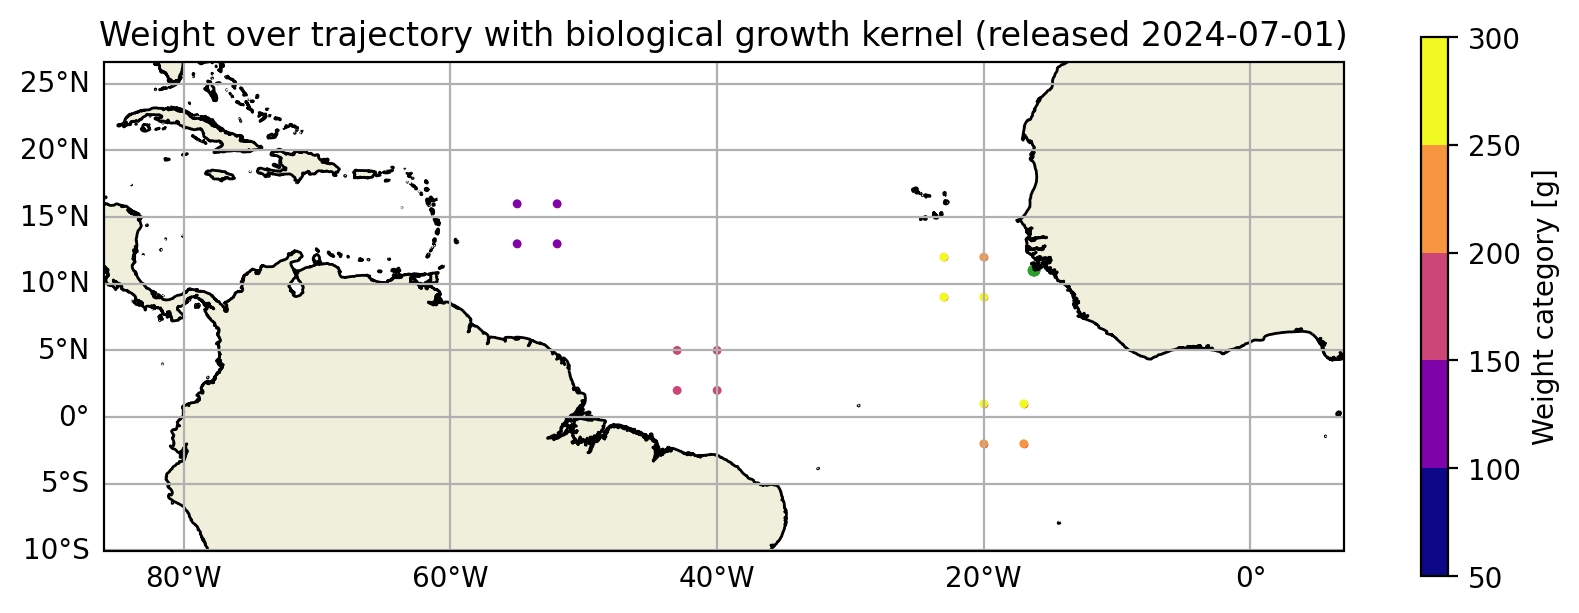

In [ ]:
fig = plt.figure(figsize = (10,7), dpi=200)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
#Startlocations scatterplot
#pplot = ax.scatter(DS_sliced.lon[:,:], DS_sliced.lat[:,:], s = 2 ,color='black') #Transposing lon and lat arrays!
pplot = ax.scatter(DSMSN.lon[:,0], DSMSN.lat[:,0], s = 3 ,color='red') #Transposing lon and lat arrays!

unique_categories = np.unique(categorized)
number_of_bins = len(unique_categories)
colormap = plt.cm.get_cmap('plasma', number_of_bins )
boundaries = np.append(unique_categories - div_step, unique_categories[-1] ) 
norm = mcolors.BoundaryNorm(boundaries, number_of_bins)
#norm = mcolors.BoundaryNorm(np.append(unique_categories.min() - 50, , unique_categories.max()+1), number_of_bins)

print(DSMSN.weight_SF3_categorized[:,-1].values)

print(DSMSN.sizes)
# Colored scatter plot
cscat = ax.scatter(
    DSMSN.lon[:,0], DSMSN.lat[:,0], c = DSMSN.weight_SF3_categorized[:,-1].values - 1,
    cmap=colormap,
    norm=norm,
    s=10,
    linewidth=0,
    transform=ccrs.PlateCarree()
)

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))

if DSMSN['stranded'].any() == 1:
    print('there are stranded particles')
    mask2 = (DSMSN['stranded']==1).compute()
    DSMSN_slice = DSMSN.where(mask2, drop=True)
    ax.scatter(DSMSN_slice.lon, DSMSN_slice.lat, c='tab:green', s=10)
else:
    print('no')

ax.set_title(f'Weight over trajectory with biological growth kernel (released {starttimejuly.date()})')
ax.set_extent([-86,7,-7,19])
cbar = plt.colorbar(cscat, ax=ax, orientation='vertical', label='Weight category [g]', shrink=0.5)
plt.show()

/tmp/ipykernel_65163/711302261.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('plasma', number_of_bins )


[150. 150. 150. ... 300. 300. 300.]
Frozen({'trajectory': 19825, 'obs': 372})
no stranded particles


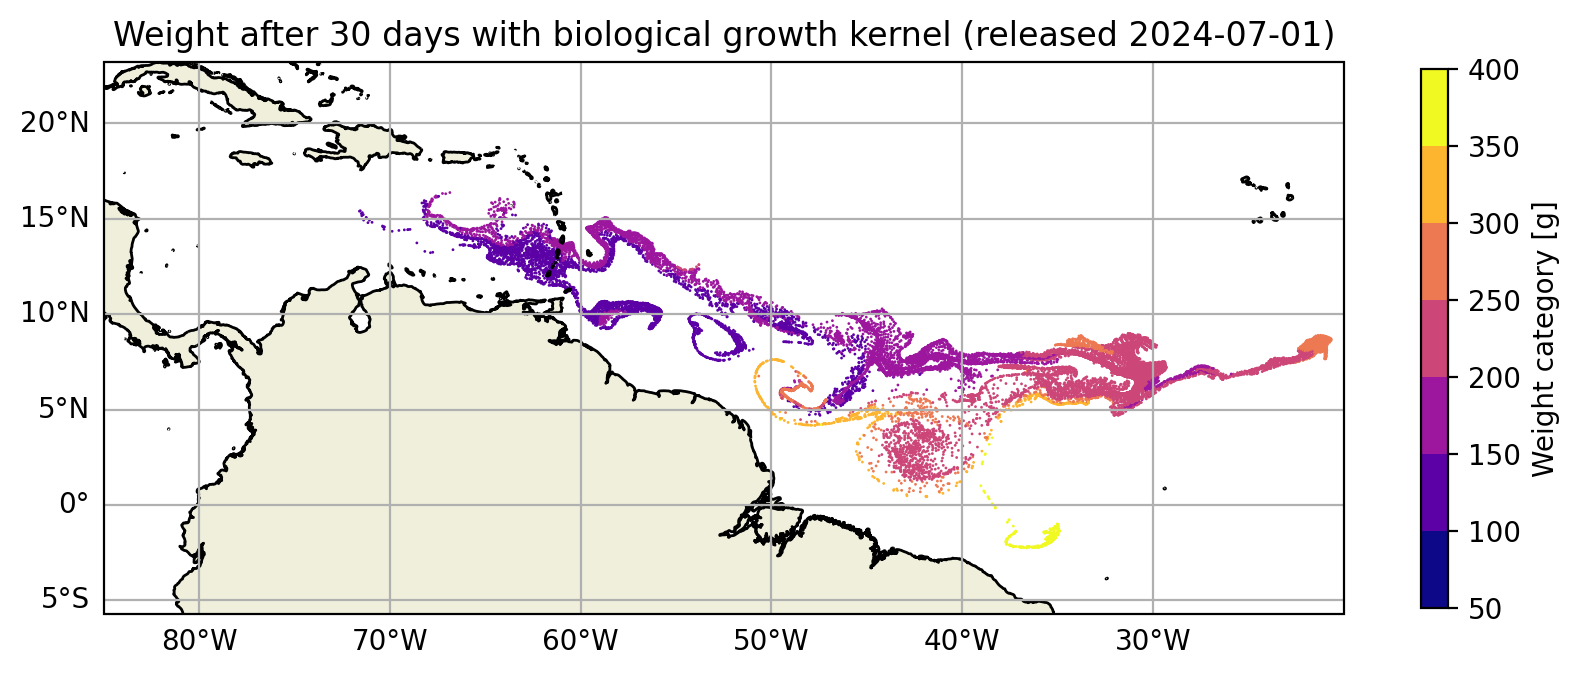

In [78]:
fig = plt.figure(figsize = (10,7), dpi=200)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.gridlines(draw_labels=['left','bottom'], zorder=0)

#Startlocations scatterplot
#pplot = ax.scatter(DSAAN.lon[:,0], DSAAN.lat[:,0], s = 3 ,color='red') #Transposing lon and lat arrays!

unique_categories = np.unique(categorized)
number_of_bins = len(unique_categories)
colormap = plt.cm.get_cmap('plasma', number_of_bins )
boundaries = np.append(unique_categories - div_step, unique_categories[-1] ) 
norm = mcolors.BoundaryNorm(boundaries, number_of_bins)
#norm = mcolors.BoundaryNorm(np.append(unique_categories.min() - 50, , unique_categories.max()+1), number_of_bins)

print(DSAAN.weight_SF3_categorized[:,-1].values)

print(DSAAN.sizes)
# Colored scatter plot
cscat = ax.scatter(
    DSAAN.lon[:,-1], DSAAN.lat[:,-1], c = DSAAN.weight_SF3_categorized[:,-1].values - 1,
    cmap=colormap,
    norm=norm,
    s=1,
    linewidth=0,
    transform=ccrs.PlateCarree()
)

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))

if DSAAN['stranded'].any() == 1:
    print('there are stranded particles')
    mask2 = (DSAAN['stranded']==1).compute()
    DSAAN_slice = DSAAN.where(mask2, drop=True)
    ax.scatter(DSAAN_slice.lon, DSAAN_slice.lat, c='tab:green', s=10)
else:
    print('no stranded particles')

ax.set_title(f'Weight after 30 days with biological growth kernel (released {starttimejuly.date()})')
#ax.set_extent([-86,7,-7,19])
ax.set_extent([-85,-20,-5,20])
cbar = plt.colorbar(cscat, ax=ax, orientation='vertical', label='Weight category [g]', shrink=0.5)
plt.show()

/tmp/ipykernel_65163/1819638202.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('plasma', number_of_bins )


[150. 150. 150. ... 300. 300. 300.]
Frozen({'trajectory': 19825, 'obs': 372})
no stranded particles


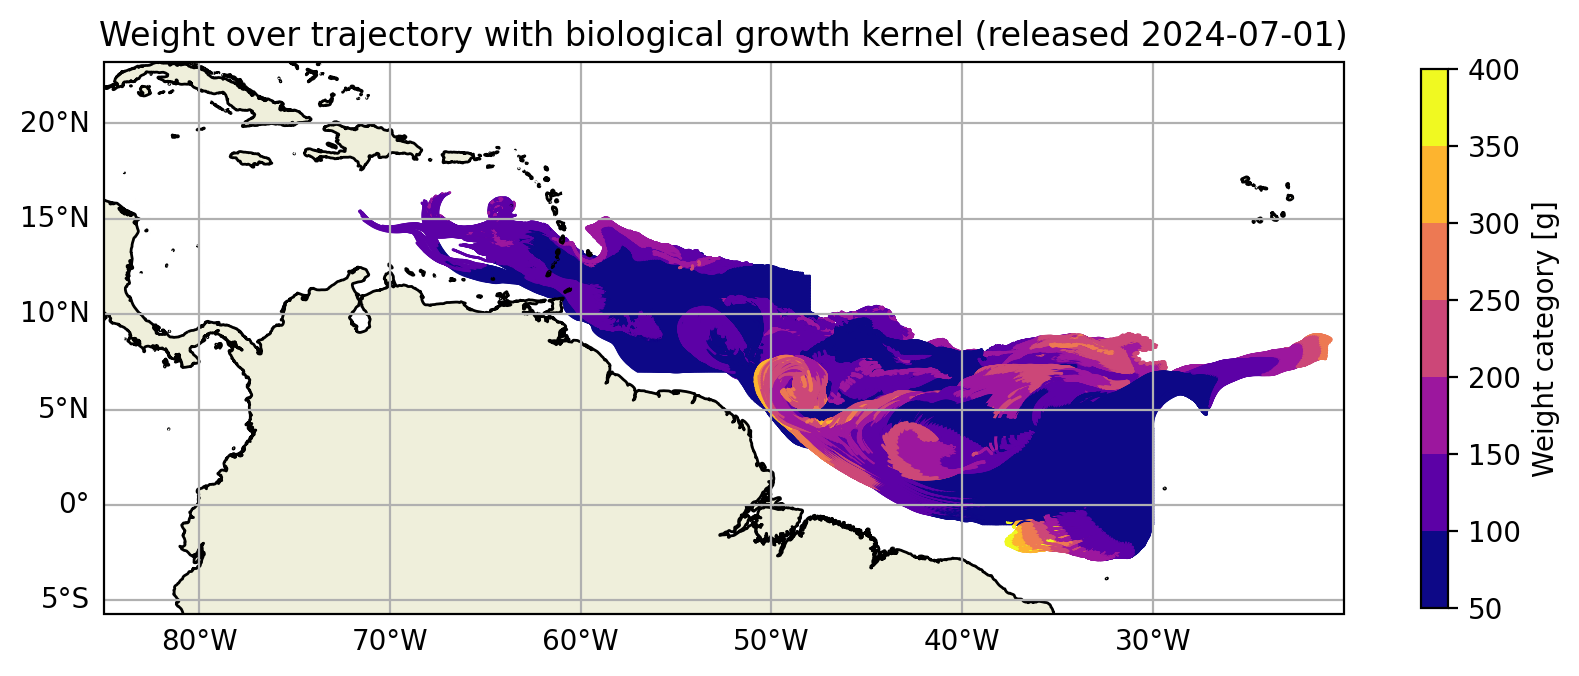

In [62]:
fig = plt.figure(figsize = (10,7), dpi=200)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.gridlines(draw_labels=['left','bottom'], zorder=0)

#Startlocations scatterplot
#pplot = ax.scatter(DSAAN.lon[:,0], DSAAN.lat[:,0], s = 3 ,color='red') #Transposing lon and lat arrays!

unique_categories = np.unique(categorized)
number_of_bins = len(unique_categories)
colormap = plt.cm.get_cmap('plasma', number_of_bins )
boundaries = np.append(unique_categories - div_step, unique_categories[-1] ) 
norm = mcolors.BoundaryNorm(boundaries, number_of_bins)
#norm = mcolors.BoundaryNorm(np.append(unique_categories.min() - 50, , unique_categories.max()+1), number_of_bins)

print(DSAAN.weight_SF3_categorized[:,-1].values)

print(DSAAN.sizes)
# Colored scatter plot
cscat = ax.scatter(
    DSAAN.lon[:,:], DSAAN.lat[:,:], c = DSAAN.weight_SF3_categorized[:,:].values - 1,
    cmap=colormap, norm=norm, s=1, linewidth=0, transform=ccrs.PlateCarree()
)

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))

if DSAAN['stranded'].any() == 1:
    print('there are stranded particles')
    mask2 = (DSAAN['stranded']==1).compute()
    DSAAN_slice = DSAAN.where(mask2, drop=True)
    ax.scatter(DSAAN_slice.lon, DSAAN_slice.lat, c='tab:green', s=10)
else:
    print('no stranded particles')

ax.set_title(f'Weight over trajectory with biological growth kernel (released {starttimejuly.date()})')
#ax.set_extent([-86,7,-7,19])
ax.set_extent([-85,-20,-5,20])
cbar = plt.colorbar(cscat, ax=ax, orientation='vertical', label='Weight category [g]', shrink=0.5)
plt.show()